In [13]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator

In [3]:
load_dotenv()

True

In [36]:
model = ChatGroq(model="openai/gpt-oss-120b")

In [56]:
class EvaluationSchema(BaseModel):

    feedback: str = Field(description="Detailed feedback on the essay")
    score: float = Field(description="Score out of 10", ge=0, le=10)

In [57]:
structured_model  = model.with_structured_output(EvaluationSchema)

In [58]:
essay = """The Impact of Artificial Intelligence on Everyday Life

Artificial Intelligence (AI) has become one of the most transformative technologies of the 21st century. Once limited to science fiction and research laboratories, AI is now integrated into many aspects of daily life. From voice assistants and recommendation systems to healthcare diagnostics and autonomous vehicles, AI is rapidly changing how people live, work, and interact with technology.

One of the most noticeable applications of AI is in digital assistants such as Siri, Alexa, and Google Assistant. These systems use natural language processing and machine learning algorithms to understand human speech and respond to queries. They help users perform tasks such as setting reminders, checking the weather, controlling smart home devices, and searching for information. By simplifying routine tasks, AI-powered assistants save time and improve convenience.

AI also plays a significant role in personalized recommendations. Platforms like Netflix, YouTube, and online shopping websites analyze user behavior to suggest content or products that match individual preferences. These systems rely on machine learning models that learn from large datasets and continuously improve their predictions. As a result, users receive more relevant suggestions, which enhances their overall experience.

In the healthcare industry, AI is helping doctors detect diseases earlier and more accurately. Machine learning models can analyze medical images such as X-rays, MRIs, and CT scans to identify abnormalities that might be difficult for humans to detect. AI is also being used to predict disease outbreaks, assist in drug discovery, and develop personalized treatment plans. These advancements have the potential to significantly improve patient outcomes and reduce healthcare costs.

Another area where AI is making a major impact is transportation. Autonomous driving technologies use AI to process data from cameras, sensors, and radar systems to navigate roads safely. Although fully self-driving cars are still under development, many modern vehicles already include AI-powered features such as lane-keeping assistance, adaptive cruise control, and automatic emergency braking.

Despite its many benefits, AI also presents several challenges. Concerns about job displacement, data privacy, and algorithmic bias are widely discussed. As AI systems become more powerful, it is important for governments, organizations, and researchers to develop ethical guidelines and regulations that ensure these technologies are used responsibly.

In conclusion, Artificial Intelligence is reshaping everyday life in profound ways. It enhances convenience, improves efficiency, and opens new possibilities across various industries. However, society must carefully address the ethical and social implications of AI to ensure that its benefits are shared widely and responsibly. As technology continues to advance, AI will likely become an even more integral part of the modern world."""

In [59]:
prompt = f"Evaluate the following essay and provide detailed feedback along with a score out of 10:\n\n{essay}"
structured_model.invoke(prompt).feedback

'The essay provides a clear, well‑structured overview of how artificial intelligence (AI) influences everyday life. It opens with a concise introduction that situates AI historically and outlines the scope of the discussion. The body paragraphs are organized by domain (digital assistants, personalized recommendations, healthcare, transportation) and each includes specific examples (Siri, Netflix, medical imaging, lane‑keeping assistance) that illustrate the technology’s impact. This logical progression helps readers follow the argument.\n\nStrengths:\n1. **Content coverage** – The essay touches on several major AI applications and briefly mentions both benefits and challenges, giving a balanced perspective.\n2. **Use of examples** – Concrete, recognizable products and services make abstract concepts tangible.\n3. **Clarity and readability** – Sentences are generally concise, jargon is limited, and the tone is appropriate for a general audience.\n4. **Structure** – Clear introduction, b

In [60]:
class EssayEvaluation(TypedDict):

    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[float], operator.add] #reducer function add(+) is used
    avg_score: float

In [61]:
def evaluate_language(state: EssayEvaluation) -> EssayEvaluation:

    prompt = f"Evaluate the language used in the following essay and provide detailed feedback along with a score out of 10:\n\n{state['essay']}"

    structured_output = structured_model.invoke(prompt)


    return {'language_feedback': structured_output.feedback, 'individual_scores': [structured_output.score]}


In [62]:
def evaluate_analysis(state: EssayEvaluation):

    prompt = f"Evaluate the analysis provided in the following essay and provide detailed feedback along with a score out of 10:\n\n{state['essay']}"

    structured_output = structured_model.invoke(prompt)


    return {'analysis_feedback': structured_output.feedback, 'individual_scores': [structured_output.score]}


In [63]:
def evaluate_clarity(state: EssayEvaluation):

    prompt = f"Evaluate the clarity of thought used in the following essay and provide detailed feedback along with a score out of 10:\n\n{state['essay']}"

    structured_output = structured_model.invoke(prompt)


    return {'clarity_feedback': structured_output.feedback, 'individual_scores': [structured_output.score]}


In [64]:
def final_evaluation(state: EssayEvaluation):

    prompt = f"Based on the following feedback, provide an overall evaluation of the essay along with a final score out of 10:\n\nLanguage Feedback: {state['language_feedback']}\n\nAnalysis Feedback: {state['analysis_feedback']}\n\nClarity Feedback: {state['clarity_feedback']}"

    output = model.invoke(prompt).content

    avg_score = sum(state['individual_scores']) / len(state['individual_scores'])

    return {'overall_feedback': output, 'avg_score': avg_score}

In [65]:
graph = StateGraph(EssayEvaluation)

graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_clarity', evaluate_clarity)
graph.add_node('final_evaluation', final_evaluation)

graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_clarity')

graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_clarity', 'final_evaluation')

graph.add_edge('final_evaluation', END)

workflow = graph.compile()





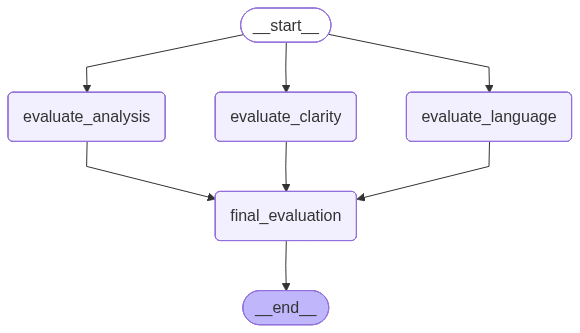

In [66]:
workflow

In [67]:
intial_state = {'essay': essay}

final_state = workflow.invoke(intial_state)

In [68]:
final_state

{'essay': 'The Impact of Artificial Intelligence on Everyday Life\n\nArtificial Intelligence (AI) has become one of the most transformative technologies of the 21st century. Once limited to science fiction and research laboratories, AI is now integrated into many aspects of daily life. From voice assistants and recommendation systems to healthcare diagnostics and autonomous vehicles, AI is rapidly changing how people live, work, and interact with technology.\n\nOne of the most noticeable applications of AI is in digital assistants such as Siri, Alexa, and Google Assistant. These systems use natural language processing and machine learning algorithms to understand human speech and respond to queries. They help users perform tasks such as setting reminders, checking the weather, controlling smart home devices, and searching for information. By simplifying routine tasks, AI-powered assistants save time and improve convenience.\n\nAI also plays a significant role in personalized recommenda

In [69]:
essay2 = '''The Importent of Internat in Humaan Life

Internat is a very bigg and powerfull thing in todays modern wrold. Many many peoples using internat everyday for diffrent works and stuffs. If internat was not exist then life will be much more harder and confusing for peoples because nowdays almost everything is conected with internat like study, shoping, comunicating, watching vedios and many other things also.

First of all internat is very helpfull for studants. Studants can serch informations in googal and watch learning vedios on youtube for understand topics better. If a studant dont understend something in class then he can immediatly open internat and find explanashun about that topic. But sometimes studants using internat for wasting time in games and scrolling social medias which is not very productiv thing.

Second important use of internat is comunication. In old times peoples was sending letters and it take many many days for reaching another place. But now with internat peoples can send message in just few seconds using apps like whatsapp or email. They can also doing vedio calls with family members who live in diffrent countrys which is very amazzing technolgy invention.

Another thing internat help with is online shoping. Many peoples like to buy things online because it is easy and not needing to go outside. Peoples can compare prize of products and read review from other peoples before buying something. But also there is some fraud peoples in internat so users should be little careful and not trust everything.

But internat also have some bad disadvantges. Many young peoples becoming too much addicted to internat and they spending lot of hours on phone and computer without doing usefull works. It also make health problems like eye straining, less excersize and sometimes sleeping problems also.

In conklusion internat is very importent inventshun for humaan life and it help peoples in many ways. But peoples should using internat in good and smart way so that it help them instead of creating problems in life.'''

In [70]:
final_state = workflow.invoke({'essay': essay2})

In [71]:
final_state

{'essay': 'The Importent of Internat in Humaan Life\n\nInternat is a very bigg and powerfull thing in todays modern wrold. Many many peoples using internat everyday for diffrent works and stuffs. If internat was not exist then life will be much more harder and confusing for peoples because nowdays almost everything is conected with internat like study, shoping, comunicating, watching vedios and many other things also.\n\nFirst of all internat is very helpfull for studants. Studants can serch informations in googal and watch learning vedios on youtube for understand topics better. If a studant dont understend something in class then he can immediatly open internat and find explanashun about that topic. But sometimes studants using internat for wasting time in games and scrolling social medias which is not very productiv thing.\n\nSecond important use of internat is comunication. In old times peoples was sending letters and it take many many days for reaching another place. But now with 